In [2]:
#Exercice 1
import pandas as pd 

df=pd.read_csv('train.csv')
#verification des doublons 
print(f"there is {df.shape[0]} rows in this dataset")
print("-----------------------------")
print(f"there is {df.duplicated().sum()} duplicates in this dataset") #On trouve 0 donc il n'ya pas de doublons dans le dataset
df.drop_duplicates(inplace=True) #On supprime les doublons s'il y en avai
print("-----------------------------")
#verification après suppression des doublons 
print(f"After deleting of the duplicates , there is {df.shape[0]} rows in this dataset")









there is 891 rows in this dataset
-----------------------------
there is 0 duplicates in this dataset
-----------------------------
After deleting of the duplicates , there is 891 rows in this dataset


In [7]:
df=pd.read_csv('train.csv')

null_values_count = df.isnull().sum()
missing_values_count = df.isna().sum()

print(missing_values_count['Cabin'])

if(missing_values_count['Cabin']>0.9*df.shape[0]):
    print("the column 'Cabin' has more than 90% of missing values, so we will drop it")
else:
    print("the column 'Cabin' has less than 90% of missing values, so we will keep it")

687
the column 'Cabin' has less than 90% of missing values, so we will keep it


In [8]:
#Exercise 2 *

def Manage_missing_values(df):

    null_values_count = df.isnull().sum()
    missing_values_count = df.isna().sum()

    # isnull() et isna() sont équivalents dans Pandas et permettent de détecter les valeurs manquantes
    print(f"here are the amount of null values per column of this dataset :\n{null_values_count}")

    print("-----------------------------")

    print(f"here are the amount of missing values per column of this dataset :\n{missing_values_count}")

    try:

        for columns in df.columns:

            if(df[columns].dtype == 'object'):
                    if missing_values_count[columns]>=0.9*df.shape[0]:#verifier si le nombre de NAN est superieur à 90%
                            df=df.drop(columns,axis=1)

                            
                    # vérifier si la colonne contient du texte (variable catégorielle)
                    # dans ce cas l'imputation se fera avec le mode (valeur la plus fréquente)

                     # fillna() retourne une nouvelle Series.
                     # Avec les nouvelles versions de Pandas (Copy-on-Write),
                    # il vaut mieux réassigner directement le résultat à la colonne.
                    df[columns] = df[columns].fillna(df[columns].mode()[0])

                        # je choisis de prendre le mode pour les valeurs manquantes
                        # car il est plus adapté aux variables catégorielles

            if(df[columns].dtype == 'int64' or df[columns].dtype == 'float64'):

                # vérifier d'abord si le nombre de valeurs manquantes
                # dépasse ou est égal à 90% du nombre total de lignes

                if(missing_values_count[columns] >= 0.9 * df.shape[0]):

                    # suppression de la colonne si elle contient trop de valeurs manquantes
                    df.drop(columns, axis=1, inplace=True)

                else:

                    # pour les variables numériques j'utilise la médiane
                    # car elle résiste mieux aux valeurs extrêmes (outliers)

                    # fillna() retourne une nouvelle Series qu'il faut réaffecter
                    df[columns] = df[columns].fillna(df[columns].median())

        return df

    except Exception as e:
        print(f"An error occurred : {e}")


cleaned_df = Manage_missing_values(df)

print("-----------------------------")

print(
    f"after management of missing values, here is the new dataset :\n{cleaned_df.isnull().sum()}"
)
cleaned_df

here are the amount of null values per column of this dataset :
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
-----------------------------
here are the amount of missing values per column of this dataset :
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
-----------------------------
after management of missing values, here is the new dataset :
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [11]:
#Exercise 3

import pandas as pd

def Feature_Engineering(df):

    try:

        # ==========================
        # Family Size
        # ==========================

        # nombre total de membres de la famille
        # +1 car on compte également le passager

        df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

        print("FamilySize feature created successfully")

        # ==========================
        # Title Extraction
        # ==========================

        # Exemple :
        # Braund, Mr. Owen Harris
        # devient :
        # Mr

        df["Title"] = df["Name"].str.extract(r',\s*([^\.]+)\.')

        print("Title feature created successfully")

        # ==========================
        # One Hot Encoding
        # ==========================

        # transformation du titre en colonnes numériques

        df = pd.get_dummies(
            df,
            columns=["Title"],
            dtype=int
        )

        print("Title encoded successfully")

        return df

    except Exception as e:

        print(f"An error occurred : {e}")

featured_df = Feature_Engineering(cleaned_df)
featured_df

FamilySize feature created successfully
Title feature created successfully
Title encoded successfully


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir,Title_the Countess
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,0,0,0,0,1,0,0,0,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,0,0,0,0,0,1,0,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,0,1,0,0,0,0,0,0,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,0,0,0,0,0,1,0,0,0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,...,0,0,0,0,0,0,0,1,0,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,...,0,1,0,0,0,0,0,0,0,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,...,0,1,0,0,0,0,0,0,0,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,...,0,0,0,0,1,0,0,0,0,0


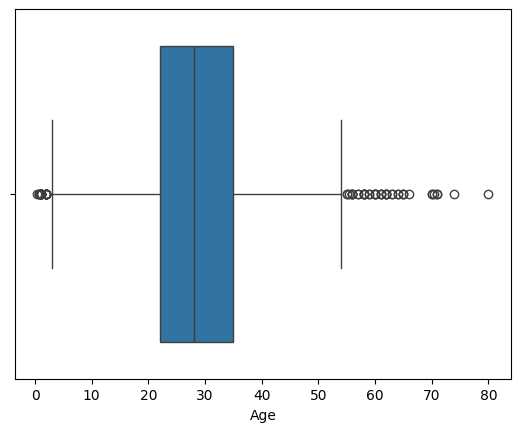

le nombre de ligne dans le dataset avant nettoyage est : 891
-------------------------------------
the number of outliers in the column Age is : 66
-------------------------------------
the percentage of outliers in the column Age is : 8%
-------------------------------------
the column Age has more than 5% of outliers, so we will treat them
-------------------------------------
the number of outliers in the column Fare is : 107
-------------------------------------
the percentage of outliers in the column Fare is : 13%
-------------------------------------
the column Fare has more than 5% of outliers, so we will treat them
-------------------------------------


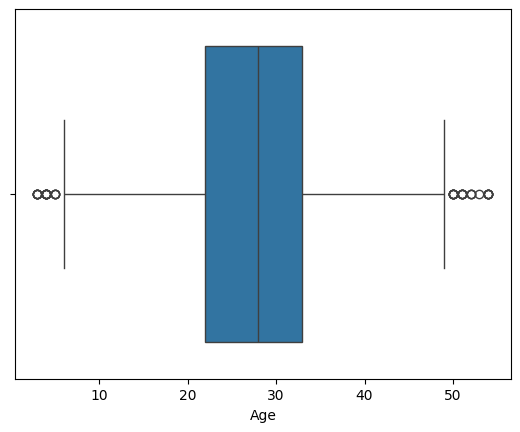

le nombre de ligne dans le dataset nettoyé est : 718


In [23]:
#Exercise 4 : Detection des valeurs aberrantes
#je vais utiliser la methode de l'IQR

import matplotlib.pyplot as plt
import seaborn as sns
import math

def visualise_distros(df,column):

    sns.boxplot(x=df[column],data=df)
    plt.show()


#visualisation avant traitement
visualise_distros(featured_df,"Age")

#debug : voir le nombre de lignes avant traitement
print(f"le nombre de ligne dans le dataset avant nettoyage est : {featured_df.shape[0]}")
print("-------------------------------------")

def Outliers_detection(df,column):

    #calcul des bornes de l'IQR

    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)

    IQR=Q3-Q1

    Lower_bound=Q1-(IQR*1.5)
    Upper_bound=Q3+(IQR*1.5)

    #recuperation des lignes contenant des valeurs aberrantes

    outliers=df[(df[column]<Lower_bound)|(df[column]>Upper_bound)]

    outlier_percentage=(outliers.shape[0]/df.shape[0])*100

    print(f"the number of outliers in the column {column} is : {outliers.shape[0]}")
    print("-------------------------------------")
    print(f"the percentage of outliers in the column {column} is : {math.ceil(outlier_percentage)}%")
    print("-------------------------------------")

    #debug
    #print(outliers)
    #outliers est un nouveau dataframe contenant uniquement les lignes identifiées comme aberrantes

    if(outlier_percentage>5 and outlier_percentage<20): #au delà de 20%  on peut se poser des questions 

        print(f"the column {column} has more than 5% of outliers, so we will treat them")
        print("-------------------------------------")

        #suppression des lignes contenant les valeurs aberrantes

        for index in outliers.index:

            df=df.drop(index)

        return df

    else:

        print(f"the column {column} has less than 5% of outliers, so we will keep them")
        print("-------------------------------------")

        return df


#premier nettoyage : Age
Age_cleaned_df=Outliers_detection(featured_df,"Age")

#deuxieme nettoyage : Fare
Fare_cleaned_df=Outliers_detection(Age_cleaned_df,"Fare")

#le dataframe final est celui qui a subi les deux traitements successifs
cleaned_df=Fare_cleaned_df


#visualisation apres traitement
visualise_distros(cleaned_df,"Age")

print(f"le nombre de ligne dans le dataset nettoyé est : {cleaned_df.shape[0]}")

In [ ]:
#Maintenant on peut faire de la normalization , je vais utiliser l'algorithme minMax de sklearn 
